# attrib-EDITS · edits_l2 — greedy in-silico saturation

The discrete counterfactual search. At each step we score *every* single substitution from one forward and apply the one that most reduces the predictor's fitness, until the score drops by a target margin. This is the **unconstrained (off-manifold)** search — it is allowed to pick implausible residues.

In [1]:
import os, sys
ROOT = os.path.abspath("")
while ROOT != os.path.dirname(ROOT) and not os.path.isdir(os.path.join(ROOT, "common")):
    ROOT = os.path.dirname(ROOT)
sys.path.insert(0, ROOT)                          # for `import common`
sys.path.insert(0, os.path.join(ROOT, "edits"))   # for `import edits_common`
print("repo root:", ROOT)

repo root: C:\Users\soura\code\2026\xai-starter


In [2]:
from edits_common import DEMO_SEQ, greedy_counterfactual, edit_metrics
res = greedy_counterfactual(DEMO_SEQ, target_drop=8.0, plausibility_weight=0.0)
print('metrics:', edit_metrics(res))
for (pos, wt, mut) in res['edits']:
    print(f'  {wt}{pos}{mut}')

Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

metrics: {'validity': True, 'proximity_n_edits': 2, 'plausibility': -11.671956062316895, 'fitness_drop': 11.839676856994629}
  M0W
  D45W


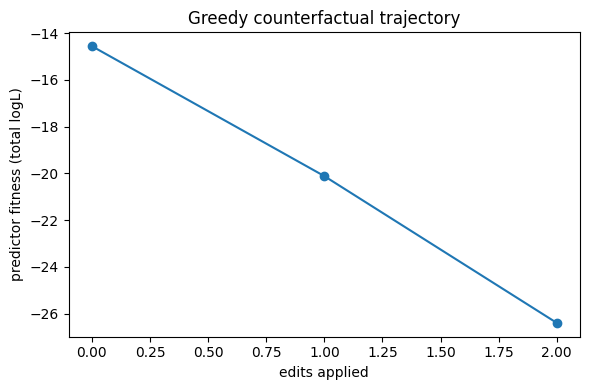

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
plt.plot(range(len(res['trajectory'])), res['trajectory'], 'o-')
plt.xlabel('edits applied'); plt.ylabel('predictor fitness (total logL)')
plt.title('Greedy counterfactual trajectory'); plt.tight_layout(); plt.show()

### Things to experiment with
- Raise `target_drop` and watch the number of edits grow.
- Note which positions get hit — they should cluster on positions the model is most confident about.